In [3]:
# ==========================================
# Standard Libraries
# ==========================================
import os
import warnings
from pathlib import Path

# ==========================================
# Data Handling
# ==========================================
import pandas as pd
import joblib

# ==========================================
# Environment Variables
# ==========================================
from dotenv import load_dotenv

# ==========================================
# Gemini
# ==========================================
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chat_models import init_chat_model

# ==========================================
# Qdrant
# ==========================================
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams

from langchain_qdrant import QdrantVectorStore

# ==========================================
# Embeddings
# ==========================================
from huggingface_hub import InferenceClient

# ==========================================
# Document Loading
# ==========================================
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import TextLoader

# ==========================================
# Text Splitting
# ==========================================
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ==========================================
# LangChain Schema
# ==========================================
from langchain_core.documents import Document

# ==========================================
# Utility
# ==========================================
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

C:\Users\mithu\AppData\Local\Temp\ipykernel_1772\2475048632.py:41: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader


In [4]:
# ==========================================
# Load Environment Variables
# ==========================================

load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

if not GOOGLE_API_KEY:
    raise ValueError("❌ GOOGLE_API_KEY not found in .env")

print("✅ Environment variables loaded")

HF_TOKEN = os.getenv("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError("❌ HF_TOKEN not found")

hf_client = InferenceClient(
    provider="hf-inference",
    api_key=HF_TOKEN
)

print("✅ HuggingFace Token Loaded")

✅ Environment variables loaded
✅ HuggingFace Token Loaded


In [5]:
# ==========================================
# Project Configuration
# ==========================================

# Model Paths
MODEL_PATH = r"D:\web-dev-projects\agri\crop-recommendation\crop_recommendation_rf_model.pkl"
ENCODER_PATH = r"D:\web-dev-projects\agri\crop-recommendation\target_encoder.pkl"

# Crop Documents
CROP_DOCS_PATH = r"D:\web-dev-projects\agri\backend-agents\crop_data"

# Qdrant
QDRANT_HOST = "localhost"
QDRANT_PORT = 6333
COLLECTION_NAME = "crop_knowledge"

# HuggingFace Embedding Model
EMBEDDING_MODEL = "BAAI/bge-m3"

print("✅ Configuration loaded")

✅ Configuration loaded


### Load Crop ML Model

In [6]:
# ==========================================
# Load Crop Recommendation Model
# ==========================================

import joblib

print("Loading Crop Recommendation Model...")

model = joblib.load(MODEL_PATH)
target_encoder = joblib.load(ENCODER_PATH)

print("✅ Random Forest Model Loaded")
print("✅ Target Encoder Loaded")

Loading Crop Recommendation Model...
✅ Random Forest Model Loaded
✅ Target Encoder Loaded


In [7]:
print(type(model))
print(type(target_encoder))

<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.preprocessing._label.LabelEncoder'>


In [8]:
# display crop classes
print(f"Total Supported Crops : {len(target_encoder.classes_)}")
print()

for i, crop in enumerate(target_encoder.classes_, start=1):
    print(f"{i:2d}. {crop}")

Total Supported Crops : 22

 1. apple
 2. banana
 3. blackgram
 4. chickpea
 5. coconut
 6. coffee
 7. cotton
 8. grapes
 9. jute
10. kidneybeans
11. lentil
12. maize
13. mango
14. mothbeans
15. mungbean
16. muskmelon
17. orange
18. papaya
19. pigeonpeas
20. pomegranate
21. rice
22. watermelon


In [9]:
# verufy model features
print(model.feature_names_in_)

['N' 'P' 'K' 'temperature' 'humidity' 'ph' 'rainfall' 'NPK_mean' 'THI'
 'ph_category' 'rainfall_level']


### Build Prediction tool

In [10]:
# ==========================================
# Feature Engineering Constants
# ==========================================

PH_CATEGORY_MAP = {
    "Acidic": 0,
    "Alkaline": 1,
    "Neutral": 2
}

RAINFALL_LEVEL_MAP = {
    "High": 0,
    "Low": 1,
    "Medium": 2,
    "Very High": 3
}

In [11]:
# ==========================================
# pH Classification
# ==========================================

def classify_ph(ph: float) -> str:
    """
    Classify soil pH into categorical ranges.
    """

    if ph < 5.5:
        return "Acidic"

    elif ph <= 7.5:
        return "Neutral"

    else:
        return "Alkaline"

In [12]:
# ==========================================
# Rainfall Classification
# ==========================================

def classify_rainfall(rainfall: float) -> str:
    """
    Categorize rainfall level.
    """

    if rainfall <= 50:
        return "Low"

    elif rainfall <= 100:
        return "Medium"

    elif rainfall <= 200:
        return "High"

    else:
        return "Very High"

In [13]:
# ==========================================
# Feature Preparation
# ==========================================

def prepare_features(
    n: float,
    p: float,
    k: float,
    temperature: float,
    humidity: float,
    ph: float,
    rainfall: float,
):
    """
    Prepare the feature dataframe expected by the ML model.
    """

    ph_category = classify_ph(ph)
    rainfall_level = classify_rainfall(rainfall)

    features = pd.DataFrame([{
        "N": n,
        "P": p,
        "K": k,
        "temperature": temperature,
        "humidity": humidity,
        "ph": ph,
        "rainfall": rainfall,
        "NPK_mean": (n + p + k) / 3,
        "THI": (temperature * humidity) / 100,
        "ph_category": PH_CATEGORY_MAP[ph_category],
        "rainfall_level": RAINFALL_LEVEL_MAP[rainfall_level],
    }])

    return {
        "features": features,
        "ph_category": ph_category,
        "rainfall_level": rainfall_level,
    }

In [14]:
# ==========================================
# Crop Prediction Tool
# ==========================================

def predict_crop(
    n: float,
    p: float,
    k: float,
    temperature: float,
    humidity: float,
    ph: float,
    rainfall: float,
):
    """
    Predict the most suitable crop.

    Returns a structured dictionary.
    """

    prepared = prepare_features(
        n,
        p,
        k,
        temperature,
        humidity,
        ph,
        rainfall,
    )

    features = prepared["features"]

    prediction = model.predict(features)[0]

    crop = target_encoder.inverse_transform([prediction])[0]

    return {

        "recommended_crop": crop,

        "input_parameters": {

            "N": n,
            "P": p,
            "K": k,
            "temperature": temperature,
            "humidity": humidity,
            "ph": ph,
            "rainfall": rainfall,

        },

        "derived_features": {

            "NPK_mean": float(features["NPK_mean"].iloc[0]),
            "THI": float(features["THI"].iloc[0]),
            "ph_category": prepared["ph_category"],
            "rainfall_level": prepared["rainfall_level"]

        }

    }

In [15]:
result = predict_crop(
    n=90,
    p=42,
    k=43,
    temperature=20.8,
    humidity=82,
    ph=6.5,
    rainfall=202,
)

result

{'recommended_crop': 'rice',
 'input_parameters': {'N': 90,
  'P': 42,
  'K': 43,
  'temperature': 20.8,
  'humidity': 82,
  'ph': 6.5,
  'rainfall': 202},
 'derived_features': {'NPK_mean': 58.333333333333336,
  'THI': 17.056,
  'ph_category': 'Neutral',
  'rainfall_level': 'Very High'}}

Connect to Qdrant

In [16]:
from qdrant_client import QdrantClient

client = QdrantClient(
    host=QDRANT_HOST,
    port=QDRANT_PORT
)

print("✅ Connected to Qdrant")

✅ Connected to Qdrant


check collection

In [17]:
from qdrant_client.models import Distance, VectorParams

collections = client.get_collections().collections

collection_names = [c.name for c in collections]

COLLECTION_EXISTS = COLLECTION_NAME in collection_names

print(f"Collection Exists : {COLLECTION_EXISTS}")

Collection Exists : True


Create Collection Only If Needed

In [18]:
VECTOR_SIZE = 1024     # BAAI/bge-m3

In [19]:
if not COLLECTION_EXISTS:

    client.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=VectorParams(
            size=VECTOR_SIZE,
            distance=Distance.COSINE,
        ),
    )

    print("✅ Collection Created")

else:

    print("✅ Using Existing Collection")

✅ Using Existing Collection


Load Documents

In [20]:
loader = DirectoryLoader(
    CROP_DOCS_PATH,
    glob="*.md",
    loader_cls=TextLoader
)

documents = loader.load()

print(f"Loaded {len(documents)} documents.")

Loaded 16 documents.


Metadata

In [21]:
from pathlib import Path

for doc in documents:
    source = Path(doc.metadata["source"])
    filename = source.stem.lower()

    crop_name = (
        filename
        .replace("detailed-", "")
        .replace("-report", "")
    )

    doc.metadata = {
        "crop": crop_name,
        "source": source.name,
    }

Chunk

In [22]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(documents)

for i, chunk in enumerate(chunks):
    chunk.metadata["chunk_id"] = i

print(len(chunks))

251


Initialize Vector Store

Check Existing Points

In [23]:
collection_info = client.get_collection(COLLECTION_NAME)

existing_vectors = collection_info.points_count

print(f"Vectors in Collection : {existing_vectors}")

Vectors in Collection : 502


Insert Only If Empty

In [24]:
if existing_vectors == 0:

    print("Uploading documents...\n")

    vector_store.add_documents(chunks)

    print("✅ Documents uploaded.")

else:

    print("✅ Collection already populated.")
    print("Skipping ingestion.")

✅ Collection already populated.
Skipping ingestion.


In [25]:
# ==========================================
# Embedding Function
# ==========================================

def embed_text(text: str) -> list[float]:
    """
    Generate embedding using HuggingFace Inference API.
    """

    embedding = hf_client.feature_extraction(
        text=text,
        model=EMBEDDING_MODEL,
    )

    return embedding

In [26]:
embedding = embed_text("Rice grows well in clay soil.")

print(type(embedding))
print(len(embedding))

<class 'numpy.ndarray'>
1024


Upload Chunks


In [27]:
from qdrant_client.models import PointStruct
from uuid import uuid5, NAMESPACE_DNS

points = []

for chunk in chunks:

    text = chunk.page_content

    embedding = embed_text(text)

    # Stable UUID
    point_id = str(
        uuid5(
            NAMESPACE_DNS,
            chunk.metadata["source"] + "_" + str(chunk.metadata["chunk_id"])
        )
    )

    payload = {
        "text": text,
        **chunk.metadata
    }

    points.append(
        PointStruct(
            id=point_id,
            vector=embedding,
            payload=payload
        )
    )

print(f"Prepared {len(points)} vectors.")

KeyboardInterrupt: 

Upload to Qdrant

In [ ]:
client.upsert(
    collection_name=COLLECTION_NAME,
    points=points,
)

print("✅ Crop knowledge uploaded successfully.")

✅ Crop knowledge uploaded successfully.


Retrieval Function

In [28]:
# ==========================================
# Retrieve Crop Knowledge
# ==========================================

from qdrant_client.models import (
    Filter,
    FieldCondition,
    MatchValue,
)


def retrieve_crop_context(
    crop_name: str,
    query: str = "",
    top_k: int = 5,
):
    """
    Retrieve the most relevant knowledge chunks for the predicted crop.
    """

    if not query:
        query = crop_name

    query_embedding = embed_text(query)

    results = client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_embedding,
        limit=top_k,
        query_filter=Filter(
            must=[
                FieldCondition(
                    key="crop",
                    match=MatchValue(value=crop_name.lower()),
                )
            ]
        ),
        with_payload=True,
    )

    retrieved_chunks = []

    for point in results.points:

        retrieved_chunks.append(
            {
                "score": round(point.score, 4),
                "crop": point.payload["crop"],
                "source": point.payload["source"],
                "chunk_id": point.payload["chunk_id"],
                "content": point.payload["text"],
            }
        )

    return {
        "status": "success",
        "agent": "crop_rag",
        "data": {
            "crop": crop_name,
            "query": query,
            "num_chunks": len(retrieved_chunks),
            "chunks": retrieved_chunks,
        },
    }

Test Retrieval

In [29]:
result = retrieve_crop_context(
    crop_name="maize",
    top_k=3
)

from pprint import pprint

pprint(result)

{'agent': 'crop_rag',
 'data': {'chunks': [{'chunk_id': 100,
                      'content': '# Detailed Agronomic and Technical Report on '
                                 'Maize (*Zea mays L.*)\n'
                                 '\n'
                                 'This report provides a comprehensive, '
                                 'technically rigorous compilation of maize '
                                 'cultivation practices, soil and climate '
                                 'requirements, water and nutrient management, '
                                 'crop protection protocols, and '
                                 'harvest/post-harvest operations. All '
                                 'guidelines are strictly extracted from the '
                                 'provided agronomic guides and are cited '
                                 'accordingly.\n'
                                 '\n'
                                 '---\n'
                            

In [30]:
def build_crop_context(retrieval_result):
    return "\n\n".join(
        chunk["content"]
        for chunk in retrieval_result["data"]["chunks"]
    )

Initialize Gemini

In [31]:
# ==========================================
# Initialize Gemini
# ==========================================

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=0.2,
    google_api_key=GOOGLE_API_KEY,
)

print("✅ Gemini initialized")

✅ Gemini initialized


In [32]:
# ==========================================
# Crop Agent Prompt
# ==========================================

CROP_AGENT_PROMPT = """
You are an expert agricultural assistant.

Your task is to explain why the recommended crop is suitable for the given soil
and environmental conditions.

Use ONLY the retrieved crop knowledge provided below.
Do not invent information.

If some information is not available in the retrieved context,
say that it is not available.

------------------------
Predicted Crop
------------------------

{crop}

------------------------
Input Parameters
------------------------

{input_parameters}

------------------------
Derived Features
------------------------

{derived_features}

------------------------
Crop Knowledge
------------------------

{crop_context}

------------------------

Generate a structured response containing:

1. Why this crop is recommended.
2. How the given soil conditions match the crop.
3. Key advantages of cultivating this crop.
4. Important cultivation considerations.
5. A short summary.

Do not include market prices, weather forecasts,
or government schemes.
"""

Crop Explanation Function

In [33]:
def generate_crop_explanation(
    prediction_result: dict,
    retrieval_result: dict,
):
    """
    Generate an explanation for the recommended crop.
    """

    crop_context = build_crop_context(retrieval_result)

    prompt = CROP_AGENT_PROMPT.format(
        crop=prediction_result["recommended_crop"],
        input_parameters=prediction_result["input_parameters"],
        derived_features=prediction_result["derived_features"],
        crop_context=crop_context,
    )

    response = llm.invoke(prompt)

    return {
        "status": "success",
        "agent": "crop_agent",
        "data": {
            "recommended_crop": prediction_result["recommended_crop"],
            "response": response.content,
        },
    }

Test

In [34]:
prediction = predict_crop(
    n=90,
    p=42,
    k=43,
    temperature=20.8,
    humidity=82,
    ph=6.5,
    rainfall=202,
)

retrieval = retrieve_crop_context(
    crop_name=prediction["recommended_crop"],
)

result = generate_crop_explanation(
    prediction,
    retrieval,
)

print(result["data"]["response"])

[{'type': 'text', 'text': 'Based on the provided crop knowledge, here is the explanation for the suitability and cultivation of rice:\n\n### 1. Why This Crop is Recommended\nRice is recommended due to its adaptability to various cultivation systems that can manage different water levels. Given the "Very High" rainfall level (202), rice is suitable as it can be grown under systems like **Semi-dry Rice** (which is rainfed for the first 30-35 days) or **System of Rice Intensification (SRI)** and **Non-Puddled machine Transplanted Rice (NPTR)**, which utilize specific irrigation schedules and standing water.\n\n### 2. How the Given Soil Conditions Match the Crop\n*   **Soil Type:** The provided knowledge mentions that rice can be grown in **clay soils** and **sandy soils** (specifically for aerobic rice using drip irrigation).\n*   **Nutrients (N, P, K):** Information regarding the specific NPK requirements (90, 42, 43) for rice is **not available** in the retrieved context.\n*   **pH Leve

### Crop Agent

In [35]:
# ==========================================
# Crop Recommendation Agent
# ==========================================
import time

def crop_agent(
    n: float,
    p: float,
    k: float,
    temperature: float,
    humidity: float,
    ph: float,
    rainfall: float,
):
    """
    Complete Crop Recommendation Agent.
    """

    start_time = time.time()
    execution_time = round(time.time() - start_time, 3)

    # --------------------------------------
    # Step 1 : Predict Crop
    # --------------------------------------
    prediction = predict_crop(
        n=n,
        p=p,
        k=k,
        temperature=temperature,
        humidity=humidity,
        ph=ph,
        rainfall=rainfall,
    )

    # --------------------------------------
    # Step 2 : Retrieve Crop Knowledge
    # --------------------------------------
    retrieval = retrieve_crop_context(
        crop_name=prediction["recommended_crop"]
    )

    # --------------------------------------
    # Step 3 : Generate Explanation
    # --------------------------------------
    explanation = generate_crop_explanation(
        prediction_result=prediction,
        retrieval_result=retrieval,
    )

    # --------------------------------------
    # Step 4 : Standardized Response
    # --------------------------------------
    return {

        "status": "success",

        "agent": "crop_agent",

        "data": {

            "recommended_crop": prediction["recommended_crop"],

            "explanation": explanation["data"]["response"],

            "prediction": prediction,

            "knowledge": retrieval,

        },

        "metadata": {

            "model": "Random Forest",

            "llm": "gemini-3-flash-preview",

            "retrieved_chunks": retrieval["data"]["num_chunks"],

            "collection": COLLECTION_NAME,

            "execution_time_seconds": execution_time,

        }

    }

Test Crop Agent

In [36]:
result = crop_agent(
    n=90,
    p=42,
    k=43,
    temperature=20.8,
    humidity=82,
    ph=6.5,
    rainfall=202,
)

from pprint import pprint

pprint(result)

{'agent': 'crop_agent',
 'data': {'explanation': [{'extras': {'signature': 'EscfCsQfARFNMg+/HPrsFnZBasyrtKlogSkmIVijrk4mZUd1GK3prLsctRbg2XFzrYxXazAVOmX31VLO4GG/7sb3AT++QJ229GoswTHPrcr9R+GAku675lmhNe0R3bCZnZvp/IaFRnEvk2FGlm92RYpSVMuUhpvbT4v1Uym5oa4T1dn/jR59A2mMLD2sNNPy/QHoj5Mbm0Ev++gYoxeBJ+GZz2ShAoI1re5hVIYuqCiIQXKLvce+AU35rejj3ZH3Tf1RhNqjDONdWZWwau4eV+6EOyabbcwTTZY4lIJT5elKkAOeDpgmJqH8t0nG6nD3zL4Uz1+ldU++CwEeyRzcH7zGsiKs6wE2Bk2fDsSmLqNam+ZkQ2KU8Lk29anbaK/AKa4IFaJE+0PR/5KnHyFyMJJCqPg8o+UEZQMjKIyJzad5Dyb1ulwXcorfWEJh3jVahDJF1hh+YfRbzK5zskVbuHHGFDM+NDUW65/GuWcdH4qJdEIHiW7gYI7yLEp1swhB0ZWBTwE6xBF/F50FTnTldLoug4ECQyo0fbRhIKscZn1s36kiN5BSHHGJpjyhvyZ/+N5mJMp77bNBg4neMtiyu6bspUplyiz7pac683G5ayrvy4SyoIePfAinCE0i2LnifWVMeOpW0ff7P+AYTo5jmFYpCK2jjBE7doyEGnbdSLIG53YCDaOw5w7/SWbc7aRo7PUHaiLlLkQjrtgehchRcwdxkpjeX77VKIEtb/7Xr+XxJw4G2XKS0KgUfr2u9Th5lpuJwxaO81U1DPi81wHoghPcuk/CrvWrtudzOO1Ieq38kmwTc+0fO3Iya4aRtHZg/DdYgR7y2jC/Zi9Cxhzzj44a0rwUBCRYADYv0Gma3GFW6ODgrAsmj/b9R91epqp5OD1JWSlEipBQGawQoaXEJnVOtRj8

In [37]:
from typing import TypedDict, Dict, Any

from langgraph.graph import StateGraph
from langgraph.graph import START, END

Define the Graph State

In [38]:
# ==========================================
# Crop Agent State
# ==========================================

class CropAgentState(TypedDict):

    # ---------- User Input ----------
    input_parameters: Dict[str, Any]

    # ---------- Feature Engineering ----------
    derived_features: Dict[str, Any]

    # ---------- ML Prediction ----------
    prediction_result: Dict[str, Any]

    recommended_crop: str

    # ---------- Retrieval ----------
    retrieval_result: Dict[str, Any]

    crop_context: str

    # ---------- LLM ----------
    explanation: str

    # ---------- Final Output ----------
    response: Dict[str, Any]

node 1- input validation

In [39]:
# ==========================================
# Input Validation Node
# ==========================================

REQUIRED_FIELDS = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall",
]


def input_validation_node(state: CropAgentState):

    user_input = state["input_parameters"]

    missing = [
        field
        for field in REQUIRED_FIELDS
        if field not in user_input
    ]

    if missing:
        raise ValueError(
            f"Missing required fields: {missing}"
        )

    return {
        "input_parameters": user_input
    }

node 2 -feature engineering

In [40]:
# ==========================================
# Crop Prediction Node
# ==========================================

def crop_prediction_node(
    state: CropAgentState,
):
    """
    Predict the best crop based on user inputs.
    """

    inputs = state["input_parameters"]

    prediction_result = predict_crop(
        n=inputs["N"],
        p=inputs["P"],
        k=inputs["K"],
        temperature=inputs["temperature"],
        humidity=inputs["humidity"],
        ph=inputs["ph"],
        rainfall=inputs["rainfall"],
    )

    return {

        "prediction_result": prediction_result,

        "recommended_crop":
            prediction_result["recommended_crop"],

        "derived_features":
            prediction_result["derived_features"]

    }

node 3 crop retrival

In [41]:
# ==========================================
# Crop Retrieval Node
# ==========================================

def crop_retrieval_node(
    state: CropAgentState,
):
    """
    Retrieve crop knowledge from Qdrant.
    """

    retrieval_result = retrieve_crop_context(
        crop_name=state["recommended_crop"]
    )

    return {

        "retrieval_result": retrieval_result

    }

node 4 - context builder

In [42]:
# ==========================================
# Context Builder Node
# ==========================================

def context_builder_node(
    state: CropAgentState,
):
    """
    Build LLM context from retrieved chunks.
    """

    crop_context = build_crop_context(
        state["retrieval_result"]
    )

    return {

        "crop_context": crop_context

    }

node 5-Crop Reasoning

In [43]:
# ==========================================
# Crop Reasoning Node
# ==========================================

def crop_reasoning_node(
    state: CropAgentState,
):
    """
    Generate crop explanation using Gemini.
    """

    explanation = generate_crop_explanation(

        prediction_result=
            state["prediction_result"],

        retrieval_result=
            state["retrieval_result"]

    )

    return {

        "explanation":
            explanation["data"]["response"]

    }

node 6- response formatter

In [ ]:
# ==========================================
# Response Formatter Node
# ==========================================

def response_formatter_node(
    state: CropAgentState,
):
    """
    Create the standardized Crop Agent response.
    """

    response = {

        "status": "success",

        "agent": "crop_agent",

        "data": {

            "recommended_crop":
                state["recommended_crop"],

            "explanation":
                state["explanation"]

        },

        "metadata": {

            "retrieved_chunks":
                state["retrieval_result"]["data"]["num_chunks"],

            "collection":
                COLLECTION_NAME,

            "llm":
                "gemini-3-flash-preview",

        }

    }

    return {

        "response": response

    }

create a graph

In [45]:
# ==========================================
# Build Crop Agent Graph
# ==========================================

workflow = StateGraph(CropAgentState)

add nodes

In [46]:
# ==========================================
# Register Nodes
# ==========================================

workflow.add_node(
    "input_validation",
    input_validation_node
)

workflow.add_node(
    "crop_prediction",
    crop_prediction_node
)

workflow.add_node(
    "crop_retrieval",
    crop_retrieval_node
)

workflow.add_node(
    "context_builder",
    context_builder_node
)

workflow.add_node(
    "crop_reasoning",
    crop_reasoning_node
)

workflow.add_node(
    "response_formatter",
    response_formatter_node
)

connect the nodes

In [47]:
# ==========================================
# Connect Nodes
# ==========================================

workflow.add_edge(
    START,
    "input_validation"
)

workflow.add_edge(
    "input_validation",
    "crop_prediction"
)

workflow.add_edge(
    "crop_prediction",
    "crop_retrieval"
)

workflow.add_edge(
    "crop_retrieval",
    "context_builder"
)

workflow.add_edge(
    "context_builder",
    "crop_reasoning"
)

workflow.add_edge(
    "crop_reasoning",
    "response_formatter"
)

workflow.add_edge(
    "response_formatter",
    END
)

compile the graph

In [48]:
# ==========================================
# Compile Graph
# ==========================================

crop_agent_graph = workflow.compile()

print("✅ Crop Agent Graph Compiled")

✅ Crop Agent Graph Compiled


visualize the graph

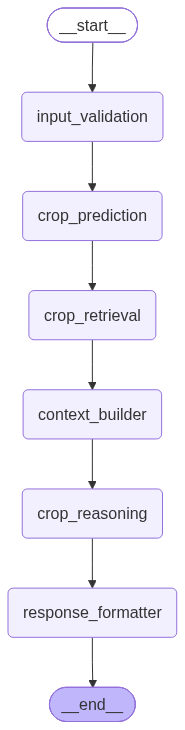

In [49]:
from IPython.display import Image, display

display(
    Image(
        crop_agent_graph.get_graph().draw_mermaid_png()
    )
)

excecute the graph

In [50]:
result = crop_agent_graph.invoke(
    {
        "input_parameters": {
            "N": 90,
            "P": 42,
            "K": 43,
            "temperature": 20.8,
            "humidity": 82,
            "ph": 6.5,
            "rainfall": 202,
        }
    }
)

inspect the result

In [51]:
from pprint import pprint

pprint(result["response"])

{'agent': 'crop_agent',
 'data': {'explanation': [{'extras': {'signature': 'Ev4kCvskARFNMg/mFK0a9N0O6xAwrGJudgdq0qeFLaOHLdigfMd0p+hoxii5clqUbN+MlV142XsVRNKW03/gGlOpx2njfQDVgNsJpp4UZf6j8Owb5lmNaCECwNK/YAkvSg8CePiBF5e/BC9B6JuMIu1aLCfueZx2LjpaCFUY78xq4sLte5cfpLvFegSK4Dtt9OHqxQ/0M/LXY5Q9X8eD868TuReH3k+lviqCxk7UOY9wA1MTXCjRoQ7yhx1vyXAiVaRr+/zsQuD/wTYlvxiOhvk3BSbTN4+3DNMP6KukNcjsg32OeLi/JVcDiFhkju6LcwuhMDYDCqXUdUWqo4mnBd3q7/6EUlKZ/cUS0GgjsyTU+CeYxVb9ue4lm3PhxcZlpLakBcHah8n8MsPy2YJf0rm9Cfvgt2HE3koZy9MpAXxU+xTXblc0nrZdgRzkQLynajqtOABMkzhH6mRZvjVfa1dO11w1IhFd5xT5/wARG7knqrYaY/wdLi99ho8X/KvMWMMdF7LX/bGCJrvlEU8IoQlJV0Q7ANK1lhFWJKK97DIM9JyC4AoNcUKe2SlmPjMwpqU3NMu6D66EjM18wROXwWh1C1frxaSxkM3sqtTclPImFuSRkd71L1ThiodR77mLy050LaNfA6UkuX71g8bjUY7O3tTqzWRnSNKR2bW50gqq8/8OywZQME56QEB0cIyRtfvKSnPmQlXJ/4S0Zurg23WwCxUl4PzsGjehYStgJJriov3n7yZuwXKNaKft/aS/GT/sboFK7f614vaHiHWggMvNJac2vrd4XaLOd9tgszPAxXT1C9KN2zyuXYS5El1ogKaplj8eCcofx4yhI87gzDHFVM+WWH+wc9x/ERYOo6T1yLIt2zTDjcmdNFMjkXLnLFy+zpd8boqIA1/QcQWHVnYYFLU5